In [1]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)


import pandas as pd
from utils.graph import dag_to_cpdag
from metrics.graph import *
from utils.results import *
from pipeline.pipeline import *

from algorithms.benchmark import run_hc, run_ea
from utils.plotting import *
from utils.data import load_csv_with_attrs
from utils.graph import *
from metrics.graph import *

## Load data

In [2]:
# JPMF Data

base_dir = "data/datasets/jpmf_data/"
# base_dir = "data/experiments/RQ1/binary_grid/"
df_num = 160
df = load_csv_with_attrs(base_dir + f"Data_Graph_{df_num}.csv")
metadata = pd.read_csv(base_dir + f"Metadata_Graph_{df_num}.csv")
true_cpdag = dag_to_cpdag(create_graph(metadata))


In [3]:
# Dataset attributes
df.attrs

{'i': 160,
 'family': 'er',
 'target_mi': 0.31699250014423125,
 'pair_probs': 0.4,
 'syn_cutoff': 0.4,
 'num_vars': 30}

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Causal Network visualisation'}>)

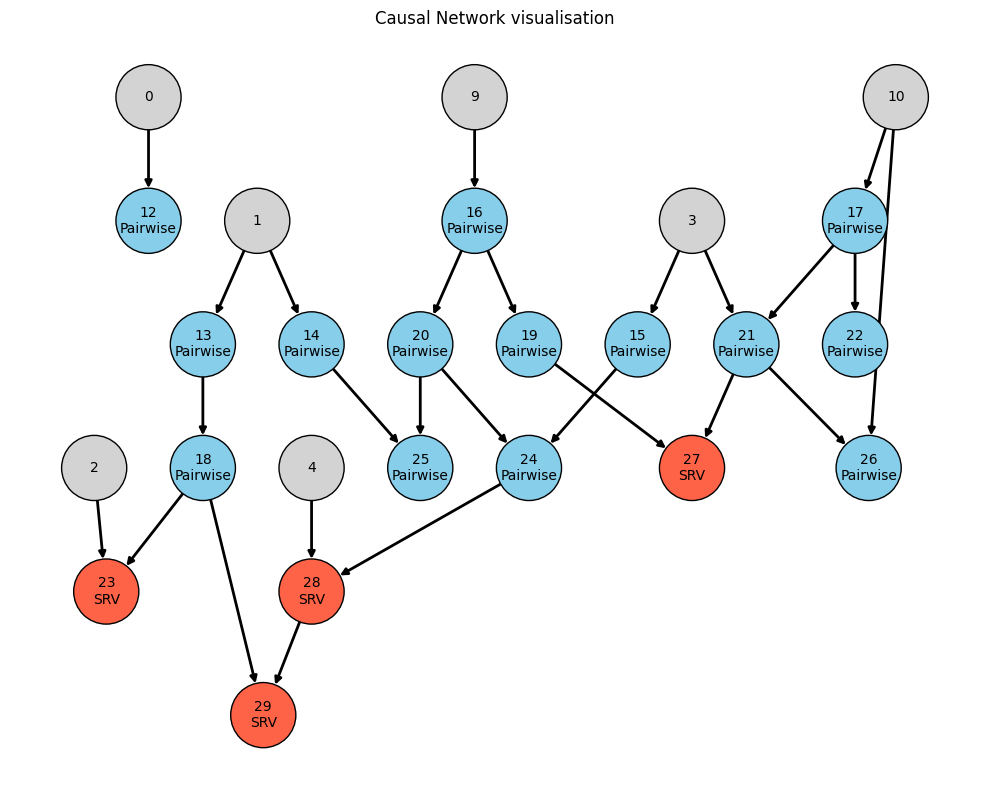

In [4]:
visualize_network_labels(metadata)

In [5]:
metadata

,Combs,Type
0,"[0, 12]",Pairwise
1,"[1, 13]",Pairwise
2,"[1, 14]",Pairwise
3,"[3, 15]",Pairwise
4,"[9, 16]",Pairwise
5,"[10, 17]",Pairwise
6,"[13, 18]",Pairwise
7,"[16, 19]",Pairwise
8,"[16, 20]",Pairwise
9,"[3, 17, 21]",Pairwise


## Compare True CPDAG with Metadata (Sanity Check)

### Skeleton metrics

In [6]:
true_skeleton_metrics = compare_cpdags(true_cpdag, create_graph(metadata))
pd.DataFrame(true_skeleton_metrics, index=["True Skeleton"]).T

,True Skeleton
n_nodes,25.0
n_pairs,300.0
SHD [Skeleton],0.0
Type Confusions [Adjacency],10.0
n_true [Adjacency],26.0
n_pred [Adjacency],26.0
TP [Adjacency],26.0
FP [Adjacency],0.0
FN [Adjacency],0.0
Precision [Skeleton],1.0


### Collider metrics

In [7]:
collider_metrics, tp, fn, fp = evaluate_colliders(metadata, dag_to_cpdag(create_graph(metadata)), df)
pd.DataFrame(collider_metrics, index=["True DAG"]).T

,True DAG
TP (Found Colliders),8.0
FP (Extra Colliders),0.0
FN (Missing Colliders ),0.0
TP (Synergistic Colliders Found),4.0
FN (Missing Synergistic Colliders),0.0
Precision [Collider],1.0
Recall [Collider],1.0
F1 [Collider],1.0
Recall [Synergy],1.0
TP (Pairwise Colliders Found),4.0


## Plain Hillclimber

In [8]:
learned_hc, score = run_hc(df)

### Skeleton metrics for HC

In [9]:
# visualize_graph(true_cpdag, title="True CPDAG")
# visualize_graph(learned_hc, title="Learned HC DAG")

In [10]:
skeleton_hc_metrics = compare_cpdags(true_cpdag, learned_hc)
pd.DataFrame(skeleton_hc_metrics, index=["HC"]).T

,HC
n_nodes,25.000000
n_pairs,300.000000
SHD [Skeleton],4.000000
Type Confusions [Adjacency],2.000000
n_true [Adjacency],26.000000
n_pred [Adjacency],28.000000
TP [Adjacency],25.000000
FP [Adjacency],3.000000
FN [Adjacency],1.000000
Precision [Skeleton],0.892857


In [11]:
collider_metrics_hc, correct, missing, extra = evaluate_colliders(metadata, learned_hc, df)
pd.DataFrame(collider_metrics_hc, index=["HC"]).T

,HC
TP (Found Colliders),6.00
FP (Extra Colliders),2.00
FN (Missing Colliders ),2.00
TP (Synergistic Colliders Found),2.00
FN (Missing Synergistic Colliders),2.00
Precision [Collider],0.75
Recall [Collider],0.75
F1 [Collider],0.75
Recall [Synergy],0.50
TP (Pairwise Colliders Found),4.00


## Evolutionary Algorithm

In [12]:
from metrics.synergy import find_synergistic_triplets
# triplets = find_synergistic_triplets(df, inflection_point=True)
triplets = find_synergistic_triplets(df, inflection_point=True)
learned_ea, score = run_ea(df, population_size=30, generations=None, informed_ratio=1, final_greedy=False, synergy_triplets=triplets, connect_disconnected=False)


In [13]:
skeleton_ea_metrics = compare_cpdags(true_cpdag, learned_ea)
pd.DataFrame(skeleton_ea_metrics, index=["EA"]).T

,EA
n_nodes,30.000000
n_pairs,435.000000
SHD [Skeleton],17.000000
Type Confusions [Adjacency],0.000000
n_true [Adjacency],26.000000
n_pred [Adjacency],9.000000
TP [Adjacency],9.000000
FP [Adjacency],0.000000
FN [Adjacency],17.000000
Precision [Skeleton],1.000000


In [14]:
metrics_ea_colliders, correct, missing, extra = evaluate_colliders(metadata, learned_ea, df)
pd.DataFrame(metrics_ea_colliders, index=["EA"]).T

,EA
TP (Found Colliders),4.000000
FP (Extra Colliders),0.000000
FN (Missing Colliders ),4.000000
TP (Synergistic Colliders Found),4.000000
FN (Missing Synergistic Colliders),0.000000
Precision [Collider],1.000000
Recall [Collider],0.500000
F1 [Collider],0.666667
Recall [Synergy],1.000000
TP (Pairwise Colliders Found),0.000000


(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Causal Network visualisation'}>)

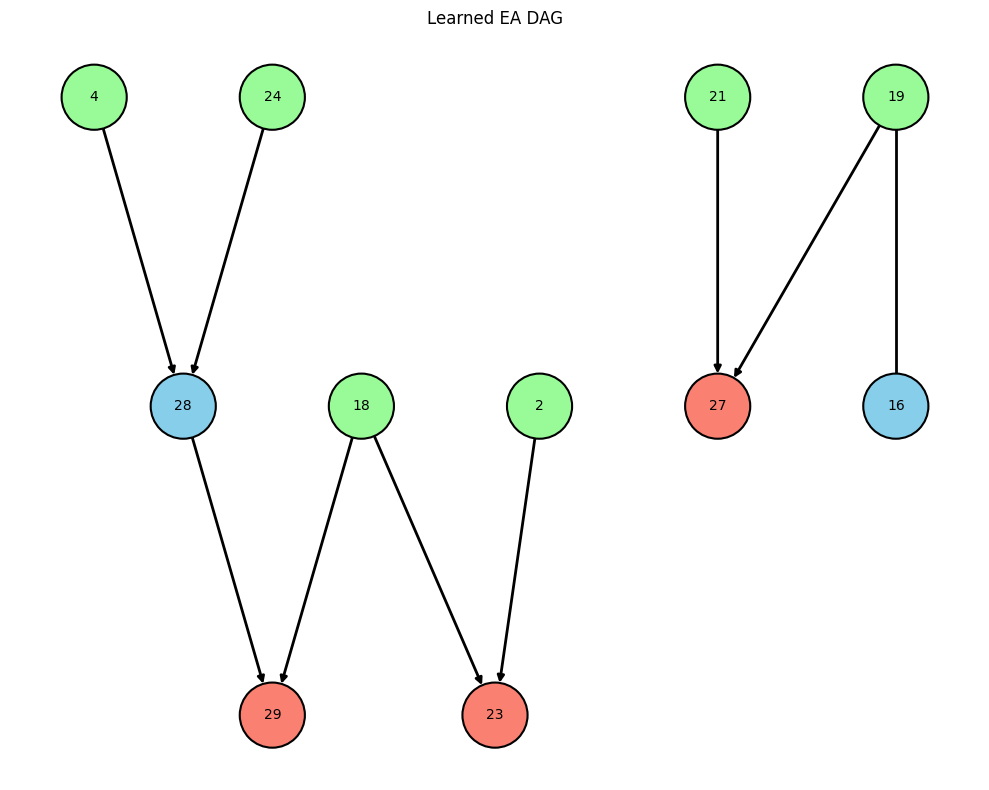

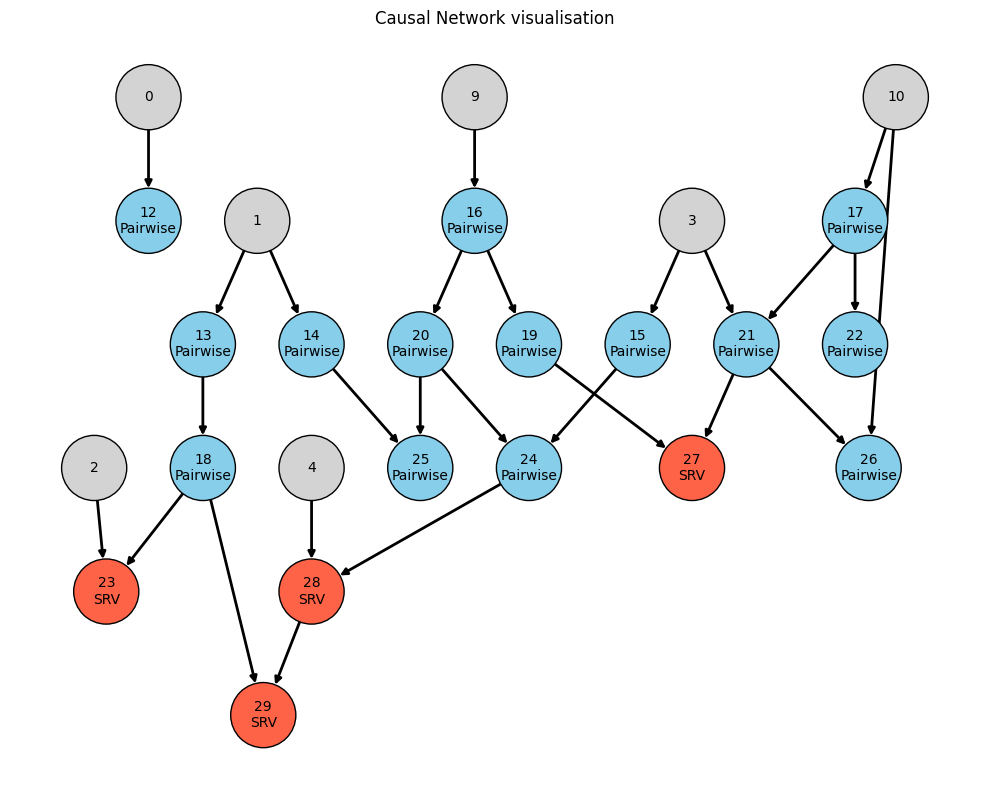

In [15]:
visualize_graph(learned_ea, title="Learned EA DAG")
visualize_network_labels(metadata)

In [16]:
metadata

,Combs,Type
0,"[0, 12]",Pairwise
1,"[1, 13]",Pairwise
2,"[1, 14]",Pairwise
3,"[3, 15]",Pairwise
4,"[9, 16]",Pairwise
5,"[10, 17]",Pairwise
6,"[13, 18]",Pairwise
7,"[16, 19]",Pairwise
8,"[16, 20]",Pairwise
9,"[3, 17, 21]",Pairwise


In [17]:
from utils.plotting import *


# fig, metrics = compare_dags_with_labels(true_cpdag, learned_hc, metadata, title="HC Learned DAG with Labels")
# fig, ax = visualize_network_labels(metadata, title="True DAG with Labels")
# visualize_graph(learned_ea, title="Learned EA CPDAG")

In [33]:
from metrics.synergy import classify_collider_by_pid
from joblib import Parallel, delayed



def categorize_synergistic_colliders(extra_colliders, df):
    # This function would implement the logic to categorize extra colliders into "synergistic" vs "pairwise"
    extra_syn = []
    extra_pairwise = []
    sorted_triplets = Parallel(n_jobs=10, backend="loky")(
    delayed(classify_collider_by_pid)(df, triplet ) for triplet in extra_colliders
    )           
    for each_triplet in sorted_triplets:
        if each_triplet["label"] == "synergistic":
            extra_syn.append(each_triplet["triplet"])
        else:
            extra_pairwise.append(each_triplet["triplet"]) 
    
    extra_syn = {tuple(map(int, triplet)) for triplet in extra_syn}
    extra_pairwise = {tuple(map(int, triplet)) for triplet in extra_pairwise}
    return extra_syn, extra_pairwise

In [34]:
correct

{(2, 18, 23), (4, 24, 28), (18, 28, 29), (19, 21, 27)}

In [35]:

extra_sn, extra_pairwise = categorize_synergistic_colliders(correct, df)

In [36]:
print("Synergistic Colliders:")
print(extra_sn)
print("Pairwise Colliders:")
print(extra_pairwise)

Synergistic Colliders:
{(19, 21, 27), (2, 18, 23), (4, 24, 28), (18, 28, 29)}
Pairwise Colliders:
set()


In [21]:
import ast
from collections import defaultdict
from dataclasses import dataclass
import itertools
from typing import Dict, FrozenSet, Iterable, Optional, Set, Tuple

import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_agraph import graphviz_layout


# -----------------------------
# Helpers for CPDAG-in-DiGraph
# -----------------------------
def pair_relation(g: nx.DiGraph, u, v) -> str:
    """
    Relation of unordered pair {u,v} in a CPDAG encoded as a single DiGraph.

    Returns one of: "none", "undirected", "u->v", "v->u"
    where "u->v" means: edge u->v exists and v->u does not.
    """
    uv = g.has_edge(u, v)
    vu = g.has_edge(v, u)

    if not uv and not vu:
        return "none"
    if uv and vu:
        return "undirected"
    if uv:
        return "u->v"
    return "v->u"


@dataclass(frozen=True)
class CPDAGSets:
    adj: Set[FrozenSet]          # skeleton edges as unordered pairs
    undirected: Set[FrozenSet]   # undirected edges as unordered pairs
    directed: Set[Tuple]         # directed edges as ordered pairs (u,v)


def cpdag_sets(g: nx.DiGraph, nodes: Iterable) -> CPDAGSets:
    nodes = list(nodes)
    undirected: Set[FrozenSet] = set()
    directed: Set[Tuple] = set()

    for u, v in itertools.combinations(nodes, 2):
        uv = g.has_edge(u, v)
        vu = g.has_edge(v, u)
        if not uv and not vu:
            continue
        if uv and vu:
            undirected.add(frozenset((u, v)))
        else:
            directed.add((u, v) if uv else (v, u))

    adj = set(undirected)
    adj.update(frozenset((u, v)) for (u, v) in directed)
    return CPDAGSets(adj=adj, undirected=undirected, directed=directed)


def _safe_div(a: float, b: float) -> float:
    return float(a / b) if b != 0 else 0.0


def _f1(p: float, r: float) -> float:
    return 0.0 if (p + r) == 0 else 2.0 * p * r / (p + r)


def shd_cpdag(true_g: nx.DiGraph, pred_g: nx.DiGraph, nodes: Iterable) -> int:
    """Type-aware CPDAG SHD: count pairs where relation differs."""
    shd = 0
    for u, v in itertools.combinations(list(nodes), 2):
        if pair_relation(true_g, u, v) != pair_relation(pred_g, u, v):
            shd += 1
    return shd


# -----------------------------
# Main plotting comparator
# -----------------------------
def compare_cpdags_with_labels(
    true_graph: nx.DiGraph,
    learned_graph: nx.DiGraph,
    metadata=None,
    title="Learned vs True CPDAG",
    logic_map=None,
    figsize=(12, 10),
    ax=None,
):
    # ---- node annotations (same as your DAG function) ----
    node_kind = defaultdict(set)
    if metadata is not None:
        for _, row in metadata.iterrows():
            comb = row["Combs"]
            if isinstance(comb, str):
                comb = ast.literal_eval(comb)
            kind = row["Type"]
            if len(comb) == 3:
                _, _, w = comb
                node_kind[w].add(kind)
            elif len(comb) == 2:
                _, v = comb
                node_kind[v].add(kind)

    # ---- align node universe ----
    nodes = sorted(set(true_graph.nodes()) | set(learned_graph.nodes()), key=lambda x: str(x))

    t = cpdag_sets(true_graph, nodes)
    p = cpdag_sets(learned_graph, nodes)

    # ---- categorize LEARNED edges vs TRUE relation ----
    # Directed learned edges: (u,v)
    dir_edges = []
    dir_colors = []
    correct_dir = set()
    wrong_dir = set()
    over_oriented = set()  # learned directed, true undirected
    extra_dir = set()      # learned directed, true none

    for (u, v) in p.directed:
        rel_t = pair_relation(true_graph, u, v)
        dir_edges.append((u, v))

        if rel_t == "u->v":
            dir_colors.append("green")
            correct_dir.add((u, v))
        elif rel_t == "v->u":
            dir_colors.append("yellow")
            wrong_dir.add((u, v))
        elif rel_t == "undirected":
            dir_colors.append("orange")
            over_oriented.add((u, v))
        else:
            dir_colors.append("red")
            extra_dir.add((u, v))

    # Undirected learned edges: {u,v}
    undir_edges = []
    undir_colors = []
    correct_undir = set()
    under_oriented = set()  # learned undirected, true directed
    extra_undir = set()     # learned undirected, true none

    for uv in p.undirected:
        u, v = sorted(tuple(uv), key=lambda x: str(x))
        rel_t = pair_relation(true_graph, u, v)
        undir_edges.append((u, v))

        if rel_t == "undirected":
            undir_colors.append("green")
            correct_undir.add(uv)
        elif rel_t in ("u->v", "v->u"):
            undir_colors.append("purple")
            under_oriented.add(uv)
        else:
            undir_colors.append("red")
            extra_undir.add(uv)

    # ---- layout: use skeleton (union helps place extra edges too) ----
    skel = nx.Graph()
    skel.add_nodes_from(nodes)
    for uv in (t.adj | p.adj):
        u, v = tuple(uv)
        skel.add_edge(u, v)

    if skel.number_of_edges() > 0:
        pos = graphviz_layout(skel, prog="dot")
    else:
        pos = nx.spring_layout(skel, seed=0)

    # ---- node labels/colors ----
    node_labels = {}
    node_colors = []
    for n in nodes:
        lines = [str(n)]
        if logic_map and n in logic_map:
            lines.append(str(logic_map[n]))
        if node_kind and n in node_kind:
            lines.append("/".join(sorted(node_kind[n])))
        node_labels[n] = "\n".join(lines)

        kinds = node_kind.get(n, set())
        if "SRV" in kinds and "Pairwise" in kinds:
            node_colors.append("violet")
        elif "SRV" in kinds:
            node_colors.append("tomato")
        elif "Pairwise" in kinds:
            node_colors.append("skyblue")
        else:
            node_colors.append("lightgrey")

    # ---- plot ----
    fig, ax2 = (ax.figure, ax) if ax is not None else plt.subplots(figsize=figsize)

    # Draw TRUE CPDAG faintly (background)
    true_undir = [(min(u, v, key=str), max(u, v, key=str)) for u, v in (tuple(e) for e in t.undirected)]
    true_dir = list(t.directed)

    # Undirected (true)
    if true_undir:
        nx.draw_networkx_edges(
            skel, pos, ax=ax2,
            edgelist=true_undir,
            edge_color="lightgrey",
            arrows=False,
            width=2,
            alpha=0.6,
        )

    # Directed (true)
    if true_dir:
        nx.draw_networkx_edges(
            true_graph, pos, ax=ax2,
            edgelist=true_dir,
            edge_color="lightgrey",
            arrows=True,
            width=2,
            alpha=0.6,
            arrowsize=18,
            min_source_margin=15,
            min_target_margin=15,
        )

    # Overlay LEARNED CPDAG (colored)
    # Learned undirected
    if undir_edges:
        nx.draw_networkx_edges(
            skel, pos, ax=ax2,
            edgelist=undir_edges,
            edge_color=undir_colors,
            arrows=False,
            width=3,
            alpha=0.95,
        )

    # Learned directed
    if dir_edges:
        nx.draw_networkx_edges(
            learned_graph, pos, ax=ax2,
            edgelist=dir_edges,
            edge_color=dir_colors,
            arrows=True,
            width=3,
            alpha=0.95,
            arrowsize=20,
            min_source_margin=15,
            min_target_margin=15,
        )

    # Draw nodes + labels on top (so edges don't hide text)
    nx.draw_networkx_nodes(
        skel, pos, ax=ax2,
        node_color=node_colors,
        node_size=2500,
        edgecolors="black",
        linewidths=1.2,
    )
    nx.draw_networkx_labels(
        skel, pos, ax=ax2,
        labels=node_labels,
        font_size=9,
    )

    # Legend
    from matplotlib.lines import Line2D
    legend_items = [
        Line2D([0], [0], color="green", lw=3, label="Correct"),
        Line2D([0], [0], color="yellow", lw=3, label="Wrong direction"),
        Line2D([0], [0], color="orange", lw=3, label="Over-oriented (true undirected)"),
        Line2D([0], [0], color="purple", lw=3, label="Under-oriented (true directed)"),
        Line2D([0], [0], color="red", lw=3, label="Extra (true none)"),
        Line2D([0], [0], color="lightgrey", lw=3, label="True CPDAG (background)"),
    ]
    ax2.legend(handles=legend_items, loc="upper left", frameon=True)

    ax2.set_title(title)
    ax2.axis("off")
    fig.tight_layout()

    # ---- metrics (optional but handy) ----
    # Adjacency (skeleton) metrics
    adj_tp = len(t.adj & p.adj)
    adj_fp = len(p.adj - t.adj)
    adj_fn = len(t.adj - p.adj)
    adj_prec = _safe_div(adj_tp, adj_tp + adj_fp)
    adj_rec = _safe_div(adj_tp, adj_tp + adj_fn)
    adj_f1 = _f1(adj_prec, adj_rec)

    # Directed metrics (strict)
    dir_tp = len(t.directed & p.directed)
    dir_fp = len(p.directed - t.directed)
    dir_fn = len(t.directed - p.directed)
    dir_prec = _safe_div(dir_tp, dir_tp + dir_fp)
    dir_rec = _safe_div(dir_tp, dir_tp + dir_fn)
    dir_f1 = _f1(dir_prec, dir_rec)

    # Undirected metrics
    undir_tp = len(t.undirected & p.undirected)
    undir_fp = len(p.undirected - t.undirected)
    undir_fn = len(t.undirected - p.undirected)
    undir_prec = _safe_div(undir_tp, undir_tp + undir_fp)
    undir_rec = _safe_div(undir_tp, undir_tp + undir_fn)
    undir_f1 = _f1(undir_prec, undir_rec)

    metrics = {
        "SHD [CPDAG]": float(shd_cpdag(true_graph, learned_graph, nodes)),
        "SHD [Skeleton]": float(len(t.adj ^ p.adj)),

        "TP [Adjacency]": float(adj_tp),
        "FP [Adjacency]": float(adj_fp),
        "FN [Adjacency]": float(adj_fn),
        "Precision [Adjacency]": float(adj_prec),
        "Recall [Adjacency]": float(adj_rec),
        "F1 [Adjacency]": float(adj_f1),

        "TP [Directed]": float(dir_tp),
        "FP [Directed]": float(dir_fp),
        "FN [Directed]": float(dir_fn),
        "Precision [Directed]": float(dir_prec),
        "Recall [Directed]": float(dir_rec),
        "F1 [Directed]": float(dir_f1),

        "TP [Undirected]": float(undir_tp),
        "FP [Undirected]": float(undir_fp),
        "FN [Undirected]": float(undir_fn),
        "Precision [Undirected]": float(undir_prec),
        "Recall [Undirected]": float(undir_rec),
        "F1 [Undirected]": float(undir_f1),

        # Edge breakdowns (useful for debugging)
        "Correct Directed": correct_dir,
        "Wrong Direction": wrong_dir,
        "Over Oriented": over_oriented,
        "Under Oriented": under_oriented,
        "Extra Directed": extra_dir,
        "Extra Undirected": extra_undir,
        "Correct Undirected": correct_undir,
    }

    return fig, metrics


(<Figure size 1200x1000 with 1 Axes>,
 {'SHD [CPDAG]': 35.0,
  'SHD [Skeleton]': 35.0,
  'TP [Adjacency]': 0.0,
  'FP [Adjacency]': 9.0,
  'FN [Adjacency]': 26.0,
  'Precision [Adjacency]': 0.0,
  'Recall [Adjacency]': 0.0,
  'F1 [Adjacency]': 0.0,
  'TP [Directed]': 0.0,
  'FP [Directed]': 8.0,
  'FN [Directed]': 16.0,
  'Precision [Directed]': 0.0,
  'Recall [Directed]': 0.0,
  'F1 [Directed]': 0.0,
  'TP [Undirected]': 0.0,
  'FP [Undirected]': 1.0,
  'FN [Undirected]': 10.0,
  'Precision [Undirected]': 0.0,
  'Recall [Undirected]': 0.0,
  'F1 [Undirected]': 0.0,
  'Correct Directed': set(),
  'Wrong Direction': set(),
  'Over Oriented': set(),
  'Under Oriented': set(),
  'Extra Directed': {('18', '23'),
   ('18', '29'),
   ('19', '27'),
   ('2', '23'),
   ('21', '27'),
   ('24', '28'),
   ('28', '29'),
   ('4', '28')},
  'Extra Undirected': {frozenset({'16', '19'})},
  'Correct Undirected': set()})

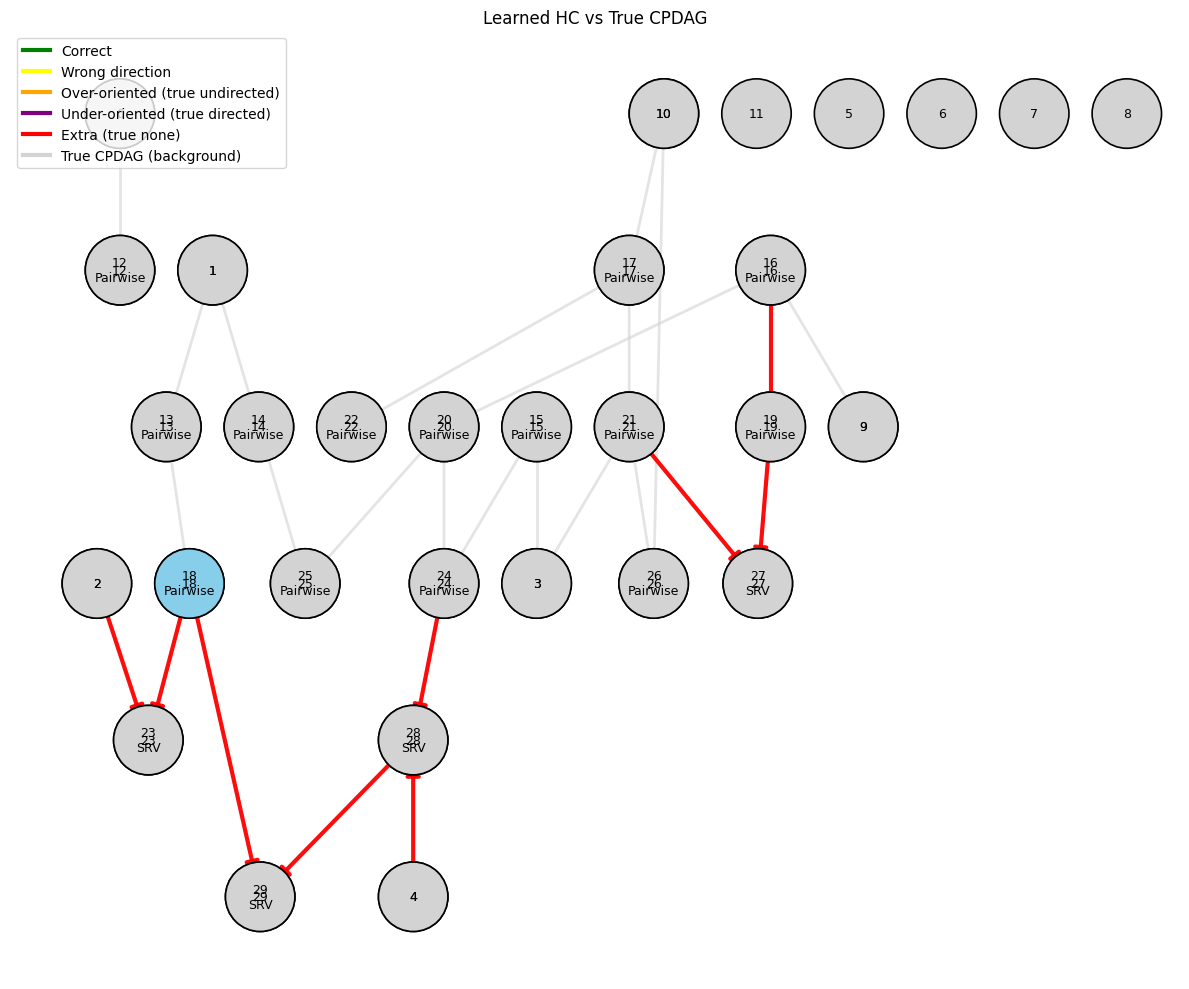

In [22]:
compare_cpdags_with_labels(true_cpdag, learned_ea, metadata=metadata, title="Learned HC vs True CPDAG")

### Informed HC

In [ ]:
from metrics.synergy import find_synergistic_triplets
triplets = find_synergistic_triplets(df)
learned_hci, score = run_ea(df, population_size=1, generations=1, informed_ratio=1, final_greedy=True, synergy_triplets=triplets)

In [ ]:
evaluate_colliders(metadata, learned_hci)

TypeError: evaluate_colliders() missing 1 required positional argument: 'dataset'

In [ ]:
synergy_triplets = find_synergistic_triplets(df)
print(f"Found {len(synergy_triplets)} synergistic triplets in the data.")

Found 30 synergistic triplets in the data.


In [ ]:
from utils.plotting import plot_three_side_by_side

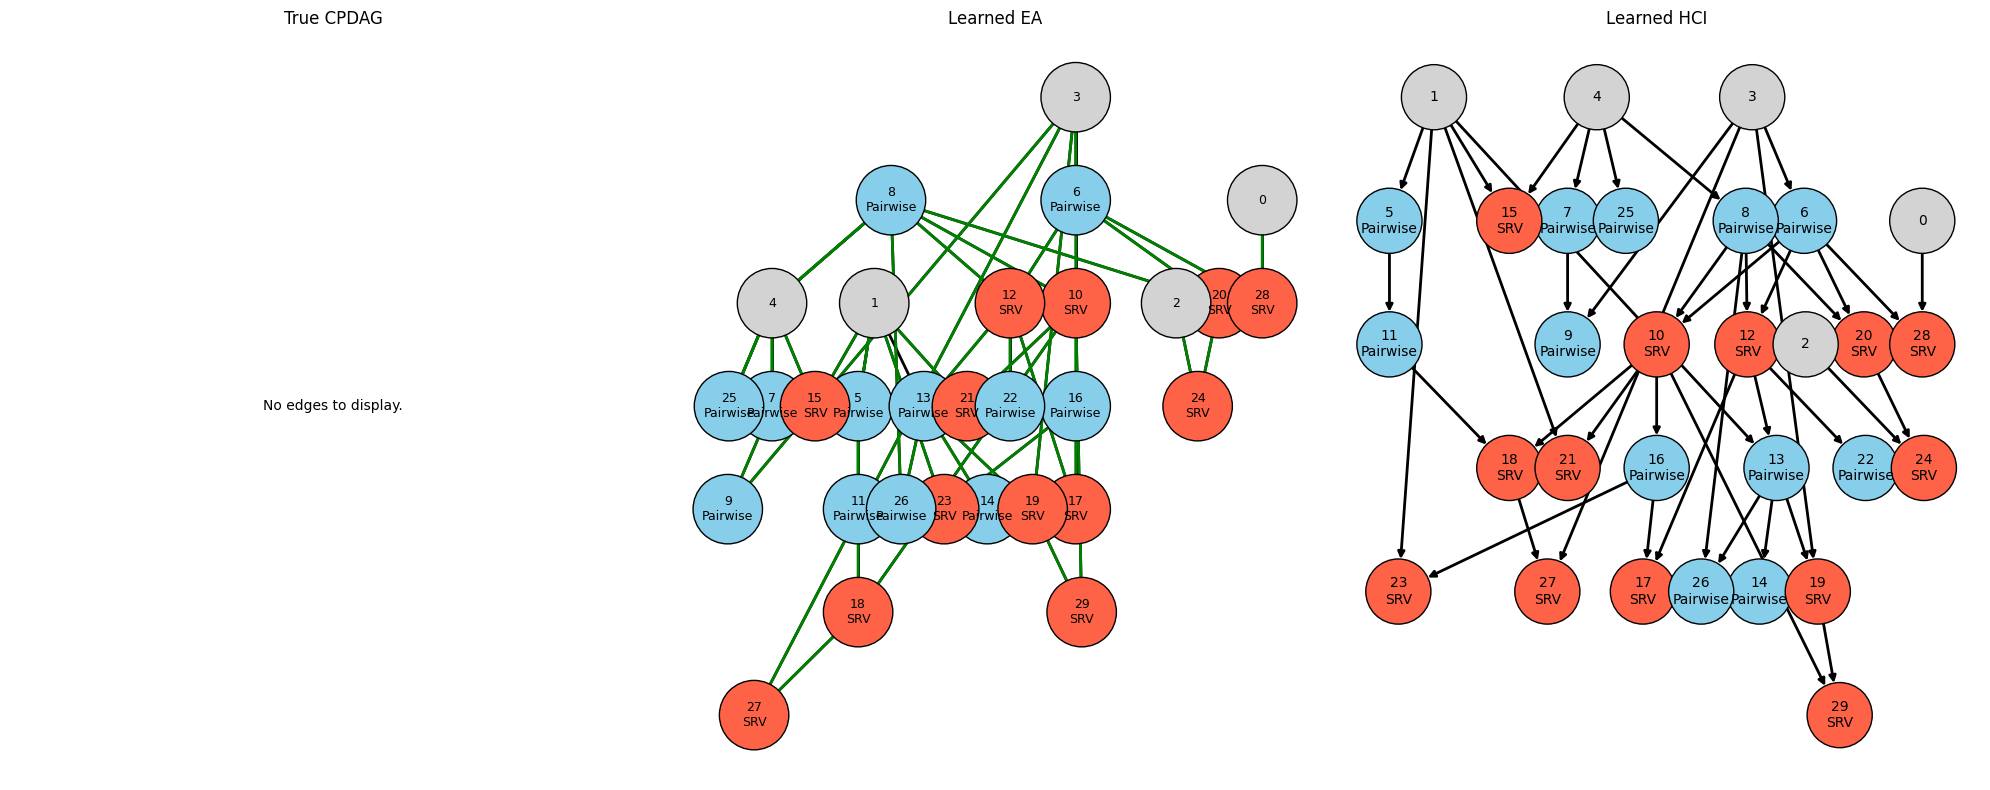

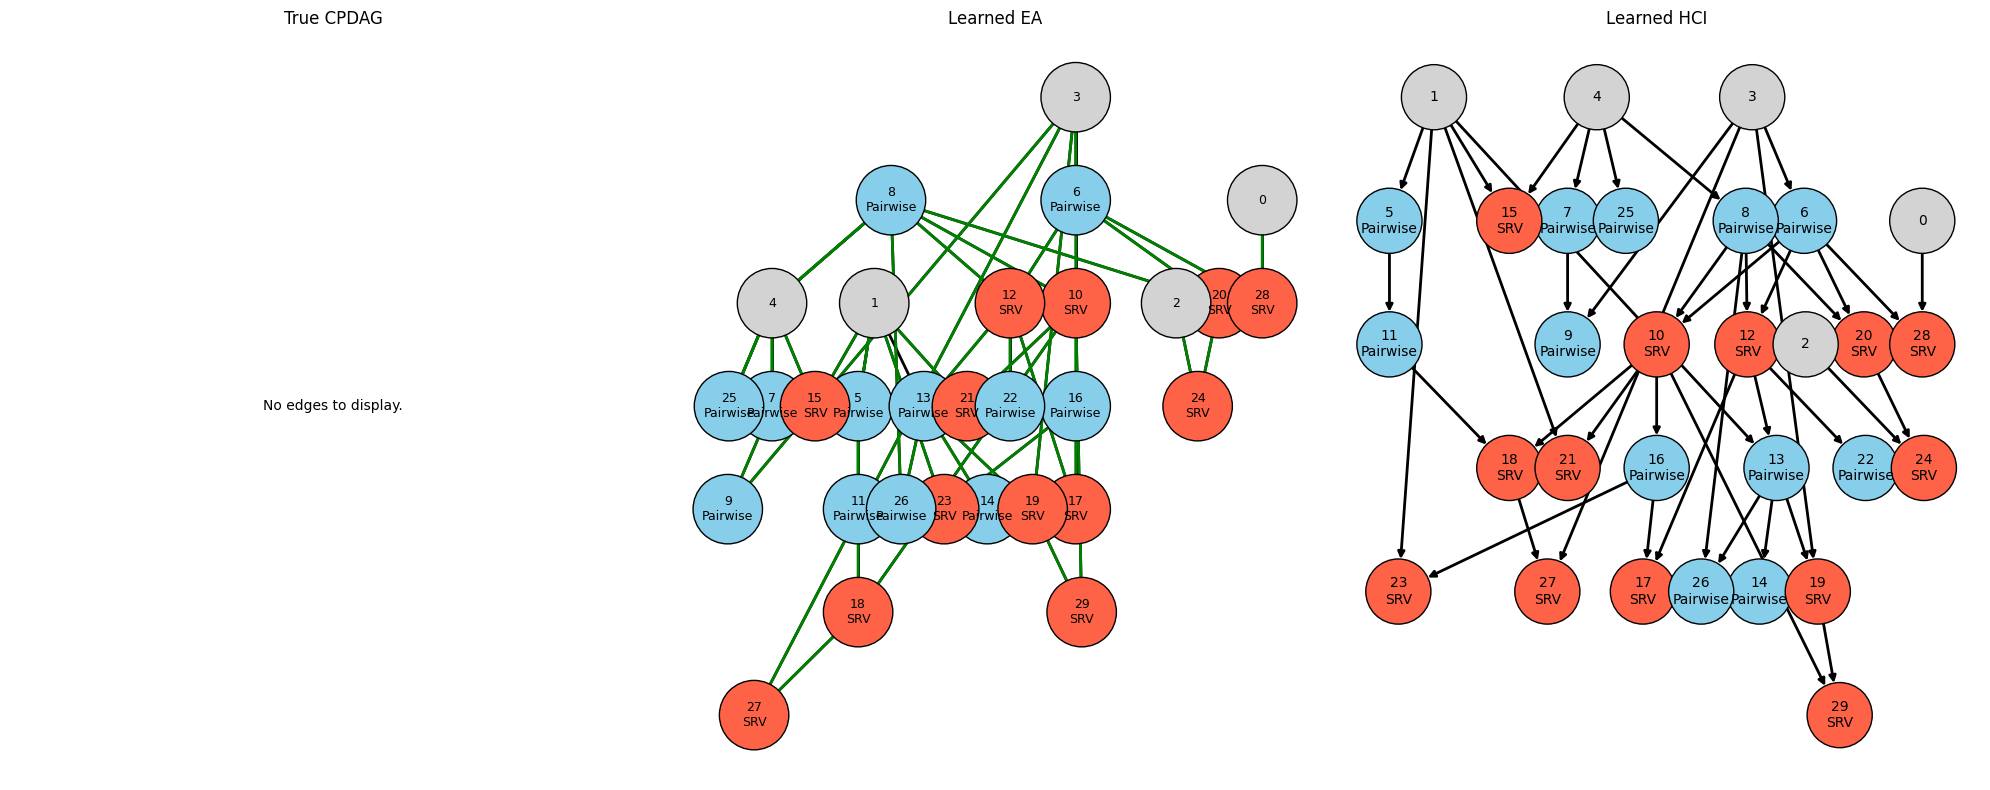

In [ ]:
plot_three_side_by_side(true_graph=true_cpdag, learned_graph=learned_ea, metadata=metadata,  titles=["True CPDAG", "Learned EA", "Learned HCI"])

In [ ]:
## EA with informed initialization and final greedy search

In [ ]:
# graph_ea, score = GeneticBNSearch(
#     df,
#     population_size=30,
#     generations=20, 
#     synergy_triplets=synergy_triplets, informed_ratio=1, final_greedy=True).run()

# eval_metrics_ea = {}
# eval_metrics_ea = compare_cpdags(true_graph=true_cpdag, learned_graph=graph_ea)
# eval_metrics_ea.update(evaluate_colliders(metadata_df=metadata, learned_dag=graph_ea))
# pd.DataFrame([eval_metrics_ea])

# # fig, metrics = compare_dags_with_labels(true_cpdag, graph, metadata=metadata, title="True vs Learned CPDAG - Hill Climbing")

In [ ]:
# graph_ihc, score  = GeneticBNSearch(
#     df,
#     population_size=1,
#     generations=1, 
#     synergy_triplets=synergy_triplets, final_greedy=True, informed_ratio=1).run()

# eval_metrics_ihc = {}
# eval_metrics_ihc = compare_cpdags(true_graph=true_cpdag, learned_graph=graph_ihc)
# eval_metrics_ihc.update(evaluate_colliders(metadata_df=metadata, learned_dag=graph_ihc))
# pd.DataFrame([eval_metrics_ihc])

In [ ]:
# compare_dags_with_labels(true_cpdag, graph_ihc, metadata=metadata, title="True vs Learned CPDAG - Informed Hill Climbing")
# # visualize_dag(graph_ihc)

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Causal Network Visualization'}>)

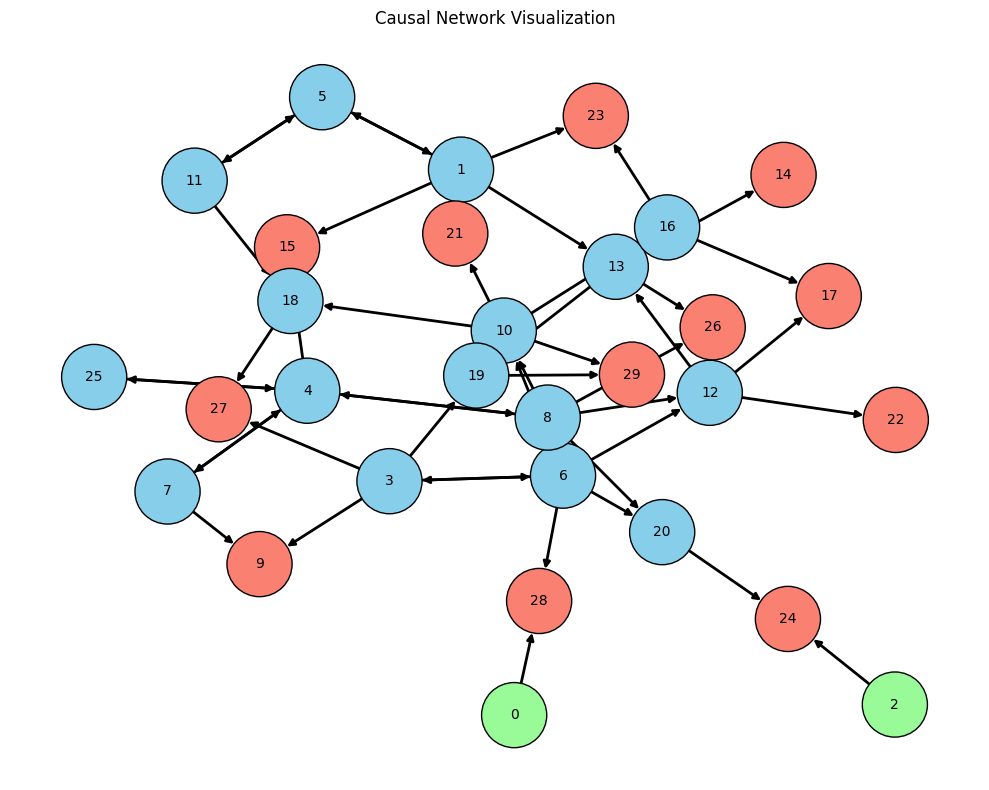

In [ ]:
visualize_dag(true_cpdag)

In [ ]:
# eval_metrics = {}
# eval_metrics = compare_cpdags(true_graph=true_cpdag, learned_graph=graph)
# eval_metrics.update(evaluate_colliders(metadata_df=metadata, learned_dag=graph))
# pd.DataFrame([eval_metrics])